In [2]:
%pip install geopy


   ---------------------------------------- 0/2 [geographiclib]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   ---------------------------------------- 2/2 [geopy]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
import pandas as pd
import numpy as np
import json
from sklearn.neighbors import BallTree
from geopy.distance import geodesic
import gzip
import json
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Make sure to change STATE_NAME for your state
STATE_NAME = "Virginia"
META_PATH = f"data/meta-{STATE_NAME}.json.gz" 
REVIEW_PATH = f"data/review-{STATE_NAME}.json.gz" 
CITIES_CSV_PATH = "data/uscities.csv"

In [7]:
def load_json_data(path, limit=None):
    data = []
    # Use gzip.open if the file ends in .gz
    open_func = gzip.open if path.endswith('.gz') else open
    
    with open_func(path, 'rt', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if limit and i >= limit: break
            data.append(json.loads(line))
    return pd.DataFrame(data)

print(f"Loading data for {STATE_NAME}...")
reviews = load_json_data(REVIEW_PATH)
metadata = load_json_data(META_PATH)

Loading data for Virginia...


In [ ]:
 # if you want to speed things up
# reviews = load_json_data(REVIEW_PATH, limit=100000)

In [11]:
#Remove closed businesses and null ratings
metadata = metadata[metadata['state'] != 'Permanently closed']
metadata = metadata.dropna(subset=['latitude', 'longitude', 'avg_rating'])
reviews = reviews.dropna(subset=['rating'])

In [18]:
#Match businesseses to the nearest city from the US Cities dataset
CITIES_CSV_PATH = "data/uscities.csv"
us_cities = pd.read_csv(CITIES_CSV_PATH)
state_cities = us_cities[us_cities['state_name'] == STATE_NAME].copy()

In [19]:
# Convert coordinates to radians for the Haversine metric
cities_rad = np.radians(state_cities[['lat', 'lng']])
business_rad = np.radians(metadata[['latitude', 'longitude']])

# Create the tree and query for the nearest city for each business
tree = BallTree(cities_rad, metric='haversine')
dist, indices = tree.query(business_rad, k=1)

In [20]:
#Assign city name back to metadata
metadata['assigned_city'] = state_cities.iloc[indices.flatten()]['city'].values

In [21]:
#APPROACH A: Relative Encompassing Area (City-Level)
print("Calculating City-Level Normalization...")

# Group by City to find the "Local Review Culture"
city_stats = metadata.groupby('assigned_city')['avg_rating'].agg(['mean', 'std', 'count']).reset_index()
city_stats.columns = ['assigned_city', 'city_avg', 'city_std', 'city_count']

metadata = metadata.merge(city_stats, on='assigned_city', how='left')

# FIX: Changed 'city_mean' to 'city_avg' to match the merge above
metadata['city_relative_z_score'] = (
    (metadata['avg_rating'] - metadata['city_avg']) / metadata['city_std']
).fillna(0)

Calculating City-Level Normalization...


In [22]:
#APPROACH B: Radii Approach (5-Mile Radius)
print("Calculating Radii Approach (5-mile neighbor stats)...")

# Earth radius in miles
EARTH_RADIUS = 3958.8
radius_mi = 5
radius_rad = radius_mi / EARTH_RADIUS

Calculating Radii Approach (5-mile neighbor stats)...


In [23]:
#Query the tree for ALL businesses within 5 miles
#Used business_rad as the tree here to compare businesses to other businesses
business_tree = BallTree(business_rad, metric='haversine')
indices_radius = business_tree.query_radius(business_rad, r=radius_rad)

def get_neighborhood_stats(idx_list):
    if len(idx_list) < 2: return np.nan
    neighborhood_ratings = metadata.iloc[idx_list]['avg_rating']
    return neighborhood_ratings.mean()

metadata['neighborhood_5mi_avg'] = [get_neighborhood_stats(idx) for idx in indices_radius]

In [24]:
#Is it better than immediate neighbors?
metadata['neighbor_diff'] = metadata['avg_rating'] - metadata['neighborhood_5mi_avg']

In [25]:
# Exporting
# Merge with review stats if needed
final_df = metadata[['gmap_id', 'name', 'assigned_city', 'avg_rating', 
                     'city_relative_z_score', 'neighborhood_5mi_avg', 'neighbor_diff']]

final_df.to_csv(f"{STATE_NAME}_Normalized_Data.csv", index=False)
print(f"Success! {STATE_NAME}_Normalized_Data.csv created.")

Success! Virginia_Normalized_Data.csv created.


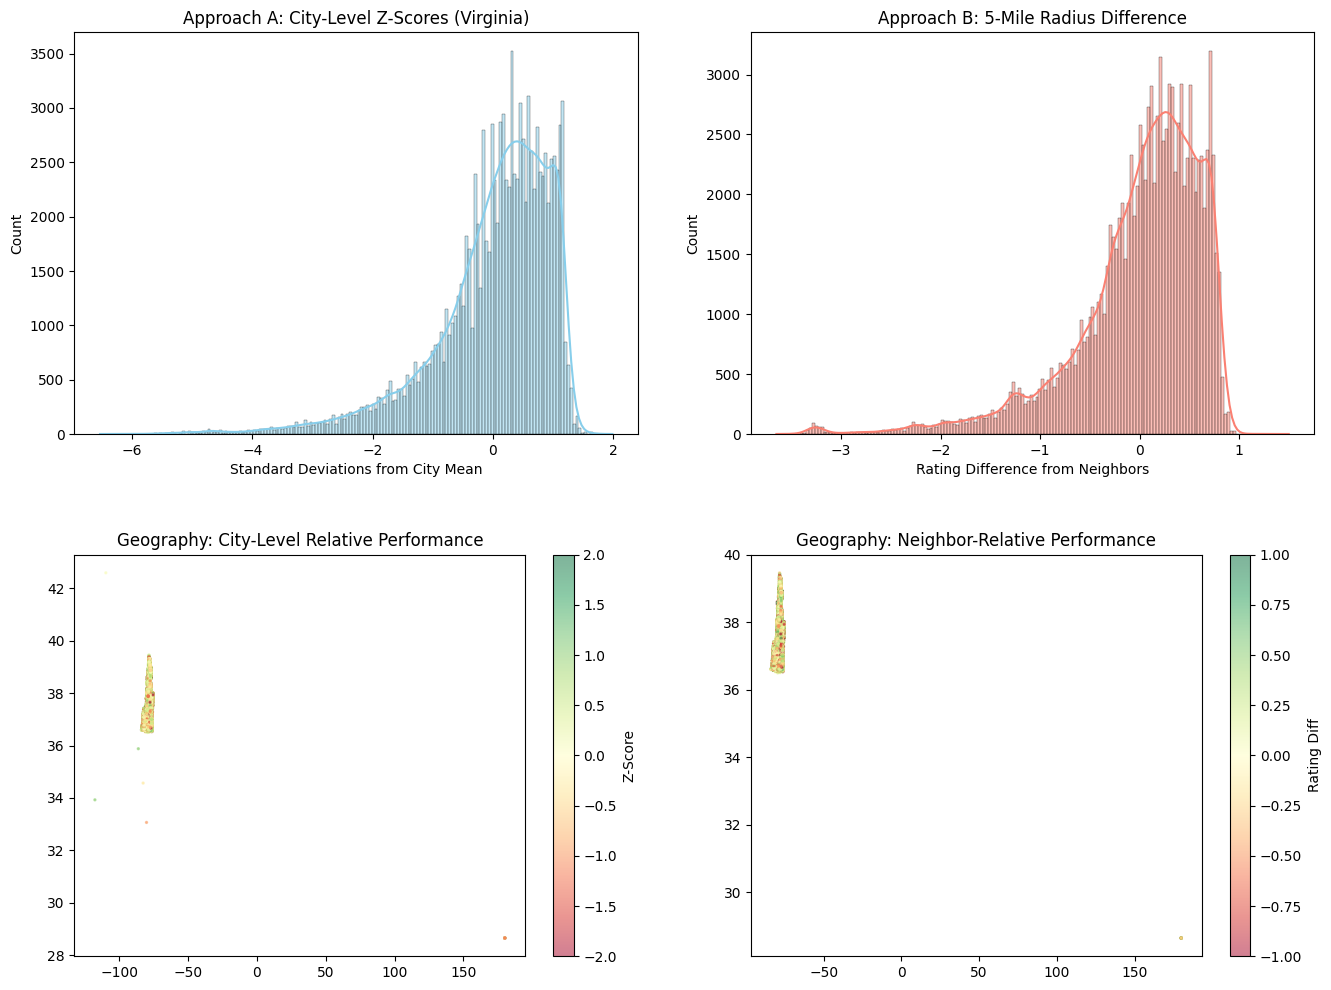

Correlation between the two approaches: 0.9848


In [29]:
# Set up the figure for a 2x2 comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.3)


# Plot A: City-Level Z-Scores
sns.histplot(metadata['city_relative_z_score'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title(f'Approach A: City-Level Z-Scores ({STATE_NAME})')
axes[0, 0].set_xlabel('Standard Deviations from City Mean')

# Plot B: 5-Mile Radius Differences
sns.histplot(metadata['neighbor_diff'].dropna(), kde=True, ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('Approach B: 5-Mile Radius Difference')
axes[0, 1].set_xlabel('Rating Difference from Neighbors')


# Map A: City Z-Score
sc1 = axes[1, 0].scatter(metadata['longitude'], metadata['latitude'], 
                         c=metadata['city_relative_z_score'], 
                         cmap='RdYlGn', s=2, alpha=0.5, vmin=-2, vmax=2)
plt.colorbar(sc1, ax=axes[1, 0], label='Z-Score')
axes[1, 0].set_title('Geography: City-Level Relative Performance')

# Map B: Neighbor Difference
sc2 = axes[1, 1].scatter(metadata['longitude'], metadata['latitude'], 
                         c=metadata['neighbor_diff'], 
                         cmap='RdYlGn', s=2, alpha=0.5, vmin=-1, vmax=1)
plt.colorbar(sc2, ax=axes[1, 1], label='Rating Diff')
axes[1, 1].set_title('Geography: Neighbor-Relative Performance')

plt.show()

# CORRELATION CHECK 
correlation = metadata['city_relative_z_score'].corr(metadata['neighbor_diff'])
print(f"Correlation between the two approaches: {correlation:.4f}")

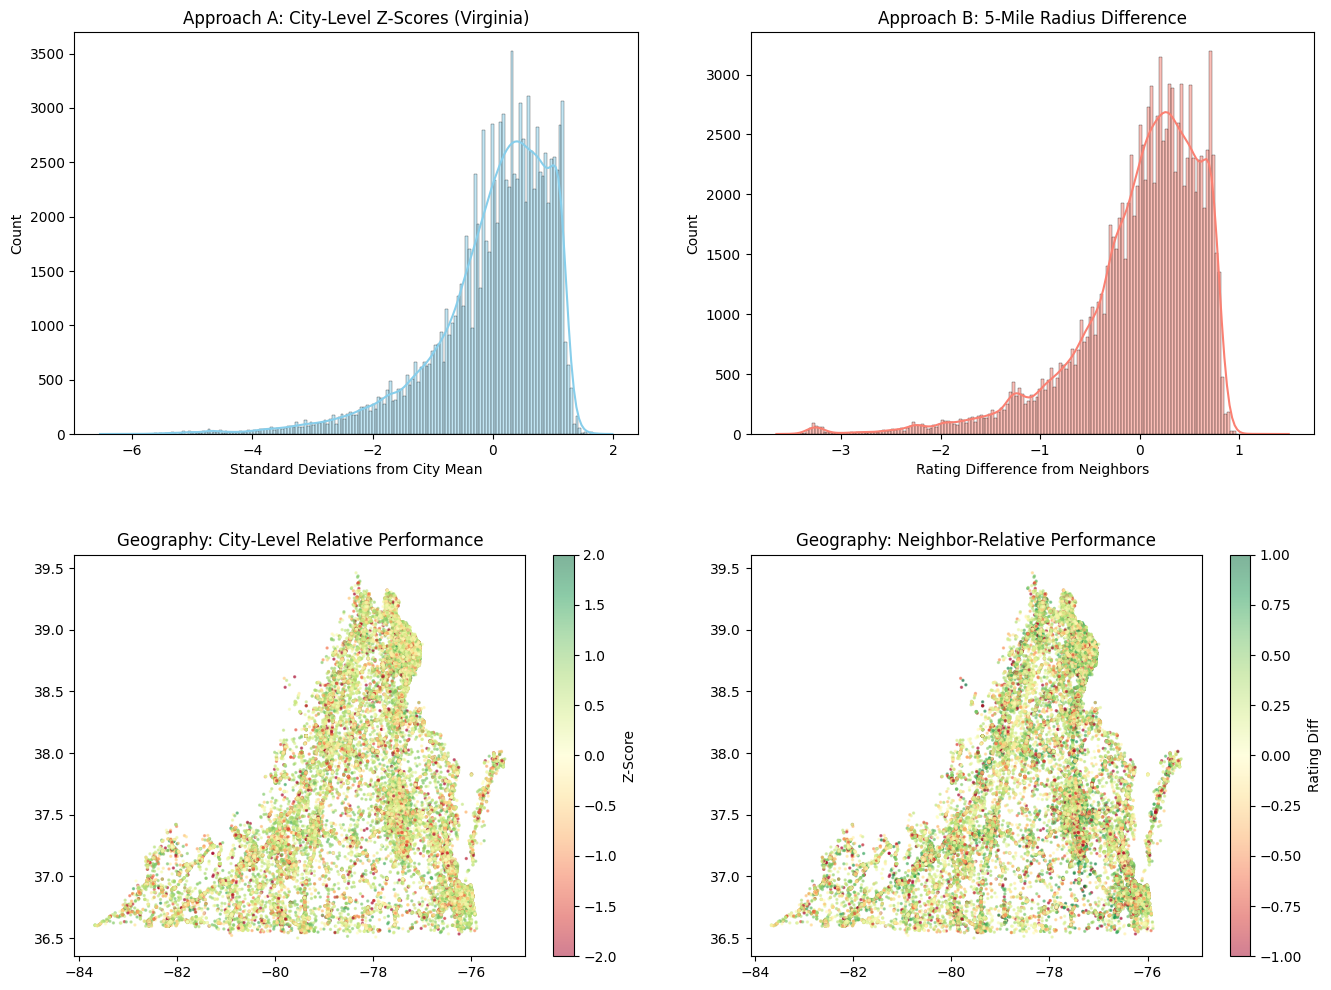

Correlation between the two approaches in Virginia: 0.9848


In [ ]:
# This removes the outliers at longitudes -120 and +180
va_metadata = metadata[
    (metadata['latitude'] > 36) & (metadata['latitude'] < 40) & 
    (metadata['longitude'] > -84) & (metadata['longitude'] < -75)
].copy()

# Set up the figure for a 2x2 comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.3)

# --- 2. DISTRIBUTION OF SCORES (using filtered data) ---

# Plot A: City-Level Z-Scores
sns.histplot(va_metadata['city_relative_z_score'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title(f'Approach A: City-Level Z-Scores ({STATE_NAME})')
axes[0, 0].set_xlabel('Standard Deviations from City Mean')

# Plot B: 5-Mile Radius Differences
sns.histplot(va_metadata['neighbor_diff'].dropna(), kde=True, ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('Approach B: 5-Mile Radius Difference')
axes[0, 1].set_xlabel('Rating Difference from Neighbors')


# --- 3. GEOGRAPHIC SPATIAL MAPS (using filtered va_metadata) ---

# Map A: City Z-Score
sc1 = axes[1, 0].scatter(va_metadata['longitude'], va_metadata['latitude'], 
                         c=va_metadata['city_relative_z_score'], 
                         cmap='RdYlGn', s=2, alpha=0.5, vmin=-2, vmax=2)
plt.colorbar(sc1, ax=axes[1, 0], label='Z-Score')
axes[1, 0].set_title('Geography: City-Level Relative Performance')

# Map B: Neighbor Difference
sc2 = axes[1, 1].scatter(va_metadata['longitude'], va_metadata['latitude'], 
                         c=va_metadata['neighbor_diff'], 
                         cmap='RdYlGn', s=2, alpha=0.5, vmin=-1, vmax=1)
plt.colorbar(sc2, ax=axes[1, 1], label='Rating Diff')
axes[1, 1].set_title('Geography: Neighbor-Relative Performance')

plt.show()

# --- 4. CORRELATION CHECK ---
correlation = va_metadata['city_relative_z_score'].corr(va_metadata['neighbor_diff'])
print(f"Correlation between the two approaches in Virginia: {correlation:.4f}")

compare category and adjust radii
what does circle map look like?
Define relative area. Could make score and performance

